In [29]:
# Se carga la librería pandas para el manejo de datos
import pandas as pd
# Se carga la librería seaborn para visualización de datos y matplotlib para mostrar gráficos
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Se carga el archivo CSV con los datos
df_empleados = pd.read_csv(r'data/HR-Employee-Attrition.csv')
df_empleados.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# Dimensiones del dataset

In [5]:
# Se usa shape para conocer las dimensiones del DataSet.
df_empleados.shape

(1470, 35)

# Frecuencia Absoluta y Relativa de la variable Attrition

In [ ]:
# Frecuencia Absoluta de la variable "Attrition"
df_empleados["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [ ]:
# Se saca el total de registros de attrition para calcular la frecuencia relativa.
Total = df_empleados["Attrition"].count()

# Se saca el total de registros por cada valor de attrition para calcular la frecuencia relativa.
valoresAtt = df_empleados["Attrition"].value_counts()

# Se sacan los valores de attrition en Yes y No para calcular la frecuencia relativa.
valoresYes = valoresAtt.iloc[1]
valoresNo = valoresAtt.iloc[0]

# Se calcula la frecuencia relativa de cada valor de attrition.
FrecuenciaRelativaYes = valoresYes / Total
FrecuenciaRelativaNo = valoresNo / Total

# Se muestran las frecuencias relativas de cada valor de attrition.
print("Frecuencia Relativa de Attrition = Yes: ", FrecuenciaRelativaYes)
print("Frecuencia Relativa de Attrition = No: ", FrecuenciaRelativaNo)

Frecuencia Relativa de Attrition = Yes:  0.16122448979591836
Frecuencia Relativa de Attrition = No:  0.8387755102040816


# ¿La distribución es balanceada o desbalanceada? ¿Qué implicaciones tiene esto para un proyecto de clasificación?

La distribución de la variable Attrition es desbalanceada, ya que se visualiza que en Yes, hay 237 empleados, representando un 16% mientras que en No, hay 1233 empleados, siendo este valor un 84% aproximadamente.

Esto quiere decir que para un proyecto de clasificación podría haber underfitting, es decir, que el modelo no tiene los datos suficientes para aprender de manera correcta, por lo cual, es necesario hacer un balanceo.

# Tabla de contingencia entre OverTime y Attrition

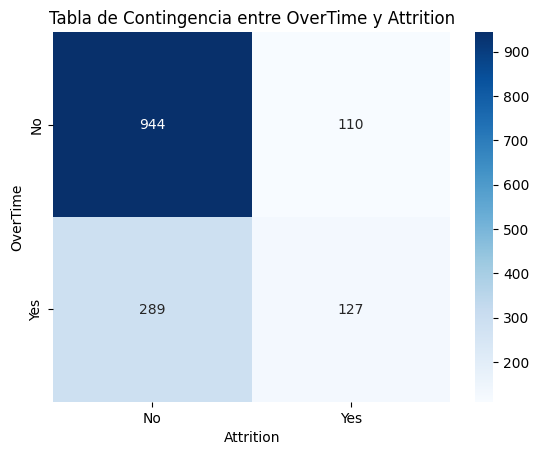

In [ ]:
# Se crea una tabla de contingencia entre las variables "OverTime" y "Attrition" con la función crosstab de pandas
tabla = pd.crosstab(df_empleados["OverTime"], df_empleados["Attrition"])

# Se muestra la tabla de contingencia con un mapa de calor utilizando seaborn
sns.heatmap(tabla, cmap="Blues",annot=True,fmt="d")
plt.title("Tabla de Contingencia entre OverTime y Attrition");

# Tabla de probabilidades conjuntas entre Overtime y Attrition

In [68]:
TablaProbConjunta = tabla/tabla.values.sum()
TablaProbConjunta

Attrition,No,Yes
OverTime,,
No,0.642177,0.074830
Yes,0.196599,0.086395


# Tabla de probabilidades condicionales

In [76]:
tabla.div(tabla.sum(axis=1),axis=0)

Attrition,No,Yes
OverTime,,
No,0.895636,0.104364
Yes,0.694712,0.305288
